## Desafio Algoritmos Supervisionados / Regressão Múltipla - Módulo 5

In [370]:
# pipenv install scikit-learn scipy pandas matplotlib seaborn ipykernel gradio pingouin

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Carregar o arquivo CSV fornecido utilizando pandas

In [371]:
# Carregar o arquivo
df_aluguel = pd.read_csv('./datasets/dataset_aluguel.csv')

### Explorar os dados utilizando as funções do pandas

In [372]:
# Verificar estrutura dos dados
df_aluguel.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     100 non-null    int64  
 1   tamanho_m2             100 non-null    float64
 2   n_quartos              100 non-null    int64  
 3   idade_casa             100 non-null    float64
 4   garagem                100 non-null    int64  
 5   localizacao_Periferia  100 non-null    bool   
 6   localizacao_Subúrbio   100 non-null    bool   
 7   valor_aluguel          100 non-null    float64
dtypes: bool(2), float64(3), int64(3)
memory usage: 5.0 KB


In [373]:
# Remover coluna id
df_aluguel.drop(columns=['id'], inplace=True)

In [374]:
# Copiar DF para DF EDA
df_aluguel_eda = df_aluguel.copy()

In [375]:
# Copiar DF para DF Bucketing
df_aluguel_bucketing = df_aluguel.copy()

In [376]:
# Visualizar os dados
df_aluguel_eda.head(10)

,tamanho_m2,n_quartos,idade_casa,garagem,localizacao_Periferia,localizacao_Subúrbio,valor_aluguel
0,106.181018,1,36.760806,0,True,False,1767.122088
1,192.607146,4,10.453581,1,True,False,3278.742397
2,159.799091,5,27.072399,1,True,False,2953.899737
3,139.798773,4,34.789220,1,False,True,2514.717108
4,73.402796,5,11.427501,0,False,True,1942.164396
5,73.399178,5,8.747746,1,True,False,2141.303241
6,58.712542,3,49.108417,1,True,False,1625.680981
7,179.926422,5,25.831795,0,False,True,2854.591908
8,140.167252,4,13.041459,1,True,False,2702.673542
9,156.210887,5,49.812685,1,False,False,2456.538289


In [377]:
# Converter idade_casa e tamanho_m2 para inteiro
df_aluguel_eda.idade_casa = df_aluguel_eda.idade_casa.astype(int)
df_aluguel_eda.tamanho_m2 = df_aluguel_eda.tamanho_m2.astype(int)
df_aluguel_eda.localizacao_Periferia = df_aluguel_eda.localizacao_Periferia.astype(int)
df_aluguel_eda.localizacao_Subúrbio = df_aluguel_eda.localizacao_Subúrbio.astype(int)

In [378]:
# Visualizar os dados transformados
df_aluguel_eda.head(10)

,tamanho_m2,n_quartos,idade_casa,garagem,localizacao_Periferia,localizacao_Subúrbio,valor_aluguel
0,106,1,36,0,1,0,1767.122088
1,192,4,10,1,1,0,3278.742397
2,159,5,27,1,1,0,2953.899737
3,139,4,34,1,0,1,2514.717108
4,73,5,11,0,0,1,1942.164396
5,73,5,8,1,1,0,2141.303241
6,58,3,49,1,1,0,1625.680981
7,179,5,25,0,0,1,2854.591908
8,140,4,13,1,1,0,2702.673542
9,156,5,49,1,0,0,2456.538289


In [379]:
# Medidas estatísticas do DF 
df_aluguel_eda.describe()

,tamanho_m2,n_quartos,idade_casa,garagem,localizacao_Periferia,localizacao_Subúrbio,valor_aluguel
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,120.020000,2.910000,25.290000,0.520000,0.280000,0.400000,2112.819084
std,44.659651,1.400541,14.397878,0.502117,0.451261,0.492366,514.314100
min,50.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1192.728727
25%,78.500000,1.750000,13.000000,0.000000,0.000000,0.000000,1694.633091
50%,119.000000,3.000000,24.000000,1.000000,0.000000,0.000000,2069.395680
75%,159.000000,4.000000,37.000000,1.000000,1.000000,1.000000,2520.182679
max,198.000000,5.000000,49.000000,1.000000,1.000000,1.000000,3278.742397


<Axes: >

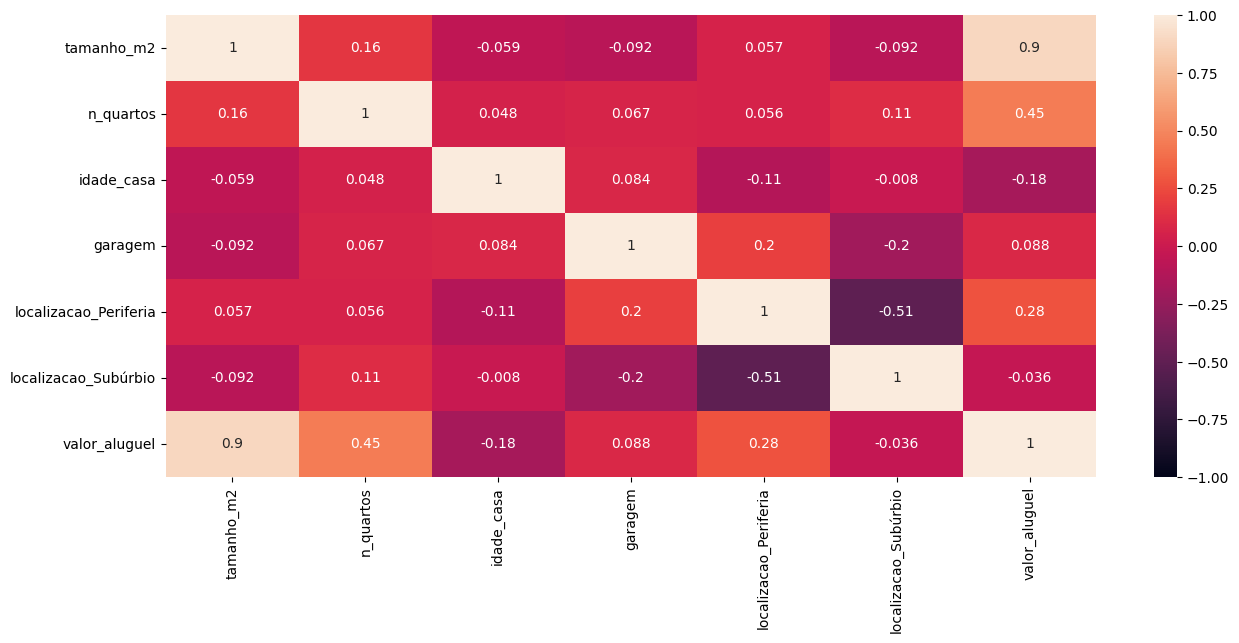

In [380]:
# Mapa de calor com correlação entre variáveis
plt.figure(figsize=(15,6))
sns.heatmap(df_aluguel_eda.corr(), vmin=-1, vmax=1, annot=True)

### Identificar e tratar valores ausentes no dataset

In [381]:
# Detectar valores ausentes
df_aluguel_eda.isna().sum()

tamanho_m2               0
n_quartos                0
idade_casa               0
garagem                  0
localizacao_Periferia    0
localizacao_Subúrbio     0
valor_aluguel            0
dtype: int64

Não foram identificados valores ausentes no dataset, então nenhum tratamento foi necessário. O SimpleImputer no pipeline é mantido como boa prática de robustez.

### Remover outliers que possam comprometer o modelo

<Axes: xlabel='tamanho_m2'>

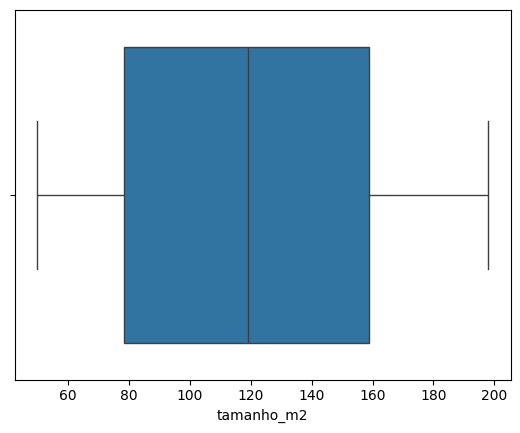

In [382]:
# Verificar / detectar outliers - tamanho_m2
sns.boxplot(data=df_aluguel_eda, x='tamanho_m2')

<Axes: xlabel='n_quartos'>

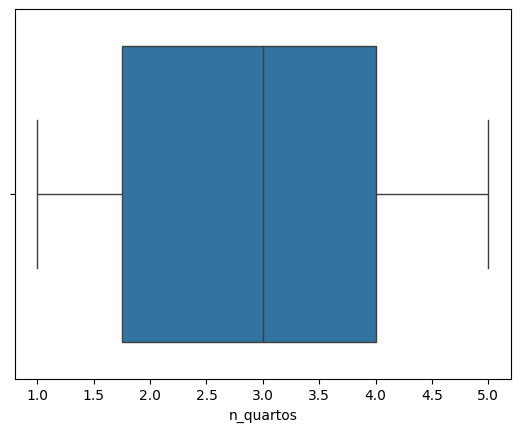

In [383]:
# Verificar / detectar outliers - n_quartos
sns.boxplot(data=df_aluguel_eda, x='n_quartos')

<Axes: xlabel='idade_casa'>

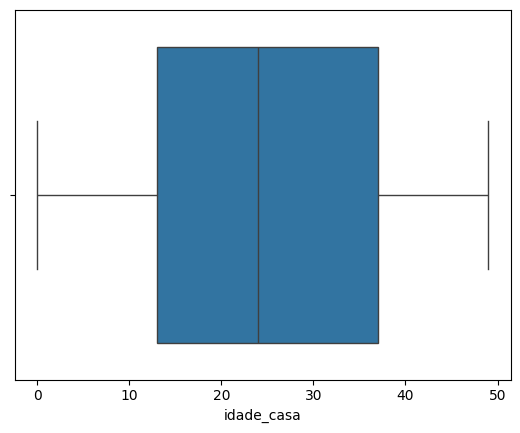

In [384]:
# Verificar / detectar outliers - idade_casa
sns.boxplot(data=df_aluguel_eda, x='idade_casa')

<Axes: xlabel='valor_aluguel'>

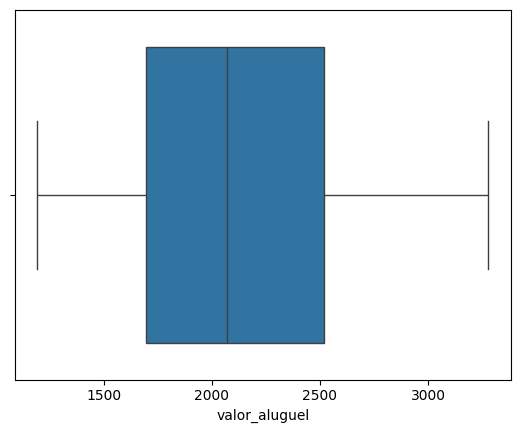

In [385]:
# Verificar / detectar outliers - valor_aluguel
sns.boxplot(data=df_aluguel_eda, x='valor_aluguel')

Os bloxplots não revelaram outliers extremos nas variáveis analisadas. Assim, todos os registros foram mantidos.

### Codificar as variáveis categóricas

<Axes: xlabel='garagem', ylabel='valor_aluguel'>

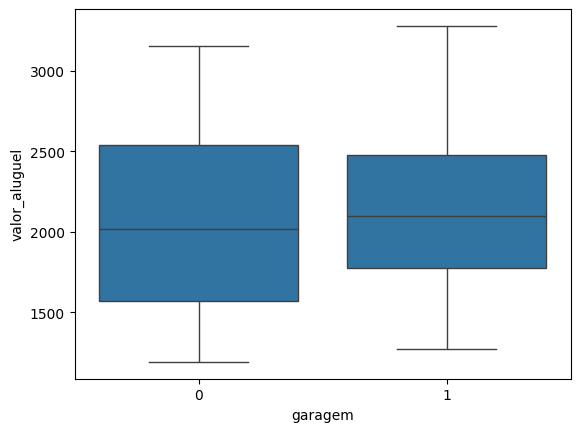

In [386]:
# Cruzamento de Variáveis Categóricas com Valor do Aluguel - Garagem
sns.boxplot(data=df_aluguel_eda, x='garagem', y='valor_aluguel')

<Axes: xlabel='localizacao_Periferia', ylabel='valor_aluguel'>

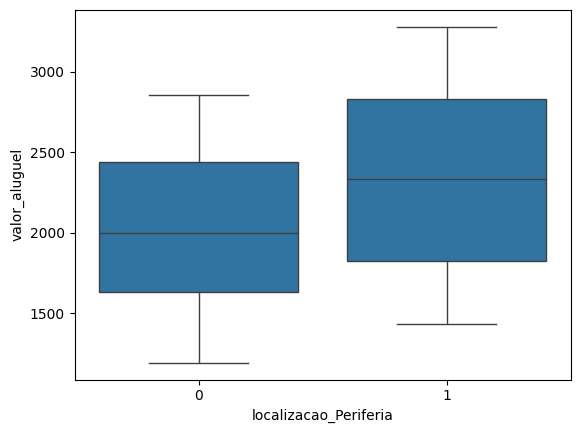

In [387]:
# Cruzamento de Variáveis Categóricas com Valor do Aluguel - Localização Periferia
sns.boxplot(data=df_aluguel_eda, x='localizacao_Periferia', y='valor_aluguel')

<Axes: xlabel='localizacao_Subúrbio', ylabel='valor_aluguel'>

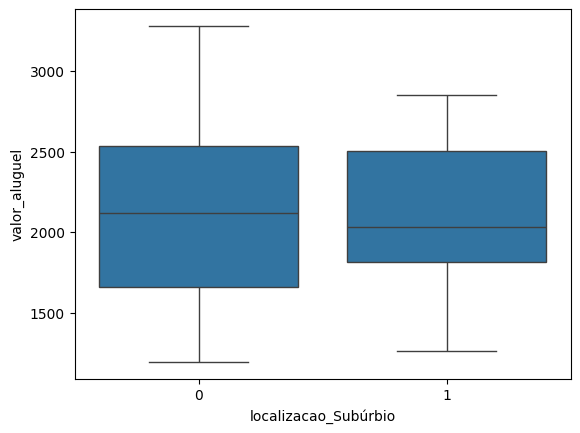

In [388]:
# Cruzamento de Variáveis Categóricas com Valor do Aluguel - Localização Subúrbio
sns.boxplot(data=df_aluguel_eda, x='localizacao_Subúrbio', y='valor_aluguel')

In [389]:
# Verificar se n_quartos é numérica ou categórica
df_aluguel_eda.n_quartos.unique()

array([1, 4, 5, 3, 2])

<Axes: xlabel='n_quartos', ylabel='valor_aluguel'>

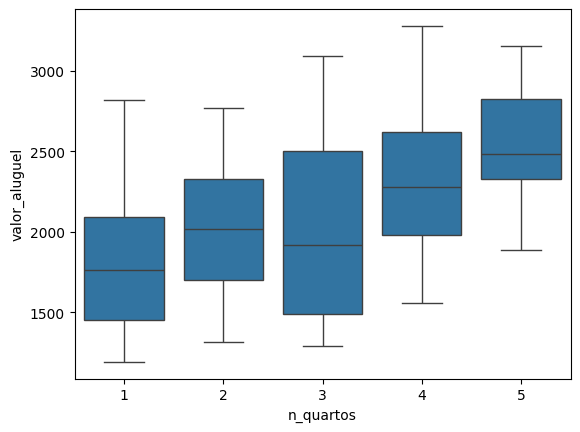

In [390]:
# Cruzamento de Variáveis Categóricas com Valor do Aluguel - Número de Quartos
sns.boxplot(data=df_aluguel_eda, x='n_quartos', y='valor_aluguel')

In [391]:
# Converter variáveis categóricas nominais em numéricas, usando One-Hot Encoder do Pandas
df_aluguel_eda = pd.get_dummies(df_aluguel_eda, columns=['n_quartos', 'garagem', 'localizacao_Periferia', 'localizacao_Subúrbio'], dtype='int64')

In [392]:
# Visualizar os dados transformados
df_aluguel_eda.head(10)

,tamanho_m2,idade_casa,valor_aluguel,n_quartos_1,n_quartos_2,n_quartos_3,n_quartos_4,n_quartos_5,garagem_0,garagem_1,localizacao_Periferia_0,localizacao_Periferia_1,localizacao_Subúrbio_0,localizacao_Subúrbio_1
0,106,36,1767.122088,1,0,0,0,0,1,0,0,1,1,0
1,192,10,3278.742397,0,0,0,1,0,0,1,0,1,1,0
2,159,27,2953.899737,0,0,0,0,1,0,1,0,1,1,0
3,139,34,2514.717108,0,0,0,1,0,0,1,1,0,0,1
4,73,11,1942.164396,0,0,0,0,1,1,0,1,0,0,1
5,73,8,2141.303241,0,0,0,0,1,0,1,0,1,1,0
6,58,49,1625.680981,0,0,1,0,0,0,1,0,1,1,0
7,179,25,2854.591908,0,0,0,0,1,1,0,1,0,0,1
8,140,13,2702.673542,0,0,0,1,0,0,1,0,1,1,0
9,156,49,2456.538289,0,0,0,0,1,0,1,1,0,1,0


### Escalar as variáveis numéricas (se necessário)

<Axes: xlabel='idade_casa', ylabel='valor_aluguel'>

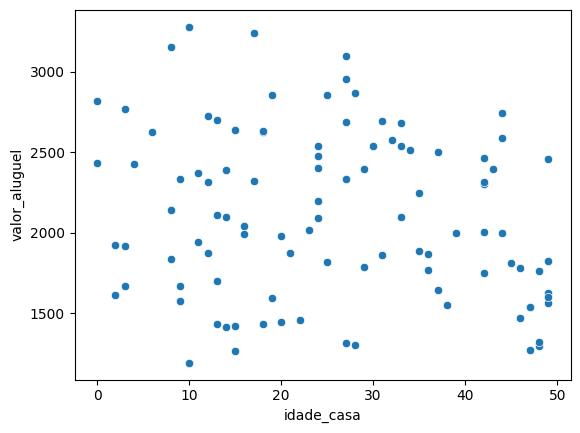

In [393]:
# Cruzamento de Variáveis Numéricas com Valor de Aluguel - Idade da Casa
sns.scatterplot(data=df_aluguel_eda, x='idade_casa', y='valor_aluguel')

<Axes: xlabel='tamanho_m2', ylabel='valor_aluguel'>

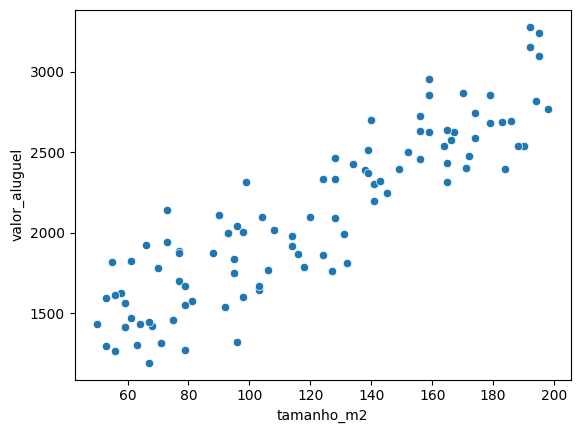

In [394]:
# Cruzamento de Variáveis Numéricas com Valor de Aluguel - Tamanho_m2
sns.scatterplot(data=df_aluguel_eda, x='tamanho_m2', y='valor_aluguel')

In [395]:
# Bucketing Idade da Casa
bins_idade_casa = [0, 10, 20, 30, 40, 50]
labels_idade_casa = ['0-9', '10-19', '20-29', '30-39', '40-49']
df_aluguel_bucketing['escala_idade_casa'] = pd.cut(x = df_aluguel_bucketing['idade_casa'], bins = bins_idade_casa, labels = labels_idade_casa, include_lowest=True)

In [396]:
# Verifical escala 
df_aluguel_bucketing.head(10)

,tamanho_m2,n_quartos,idade_casa,garagem,localizacao_Periferia,localizacao_Subúrbio,valor_aluguel,escala_idade_casa
0,106.181018,1,36.760806,0,True,False,1767.122088,30-39
1,192.607146,4,10.453581,1,True,False,3278.742397,10-19
2,159.799091,5,27.072399,1,True,False,2953.899737,20-29
3,139.798773,4,34.789220,1,False,True,2514.717108,30-39
4,73.402796,5,11.427501,0,False,True,1942.164396,10-19
5,73.399178,5,8.747746,1,True,False,2141.303241,0-9
6,58.712542,3,49.108417,1,True,False,1625.680981,40-49
7,179.926422,5,25.831795,0,False,True,2854.591908,20-29
8,140.167252,4,13.041459,1,True,False,2702.673542,10-19
9,156.210887,5,49.812685,1,False,False,2456.538289,40-49


<Axes: xlabel='escala_idade_casa', ylabel='valor_aluguel'>

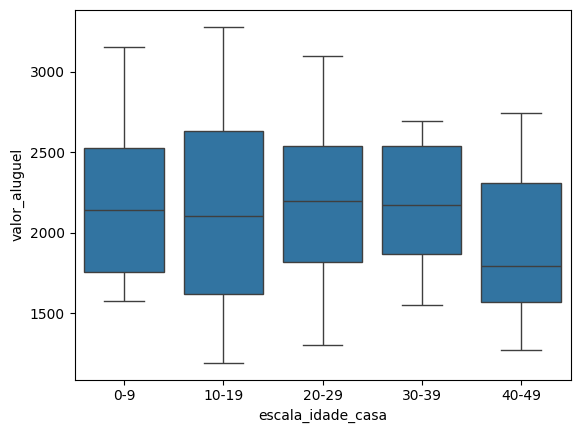

In [397]:
sns.boxplot(df_aluguel_bucketing, x='escala_idade_casa', y='valor_aluguel')

In [398]:
# Bucketing Tamanho em m^2
bins_tamanho_m2 = [50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200]
labels_tamanho_m2 = ['50-59', '60-69', '70-79', '80-89', '90-99', '100-109', '110-119', '120-129', '130-139', '140-149', '150-159', '160-169', '170-179', '180-189', '190-199']
df_aluguel_bucketing['escala_tamanho_m2'] = pd.cut(x = df_aluguel_bucketing['tamanho_m2'], bins = bins_tamanho_m2, labels = labels_tamanho_m2, include_lowest=True)

In [399]:
# Verifical escala 
df_aluguel_bucketing.head(10)

,tamanho_m2,n_quartos,idade_casa,garagem,localizacao_Periferia,localizacao_Subúrbio,valor_aluguel,escala_idade_casa,escala_tamanho_m2
0,106.181018,1,36.760806,0,True,False,1767.122088,30-39,100-109
1,192.607146,4,10.453581,1,True,False,3278.742397,10-19,190-199
2,159.799091,5,27.072399,1,True,False,2953.899737,20-29,150-159
3,139.798773,4,34.789220,1,False,True,2514.717108,30-39,130-139
4,73.402796,5,11.427501,0,False,True,1942.164396,10-19,70-79
5,73.399178,5,8.747746,1,True,False,2141.303241,0-9,70-79
6,58.712542,3,49.108417,1,True,False,1625.680981,40-49,50-59
7,179.926422,5,25.831795,0,False,True,2854.591908,20-29,170-179
8,140.167252,4,13.041459,1,True,False,2702.673542,10-19,140-149
9,156.210887,5,49.812685,1,False,False,2456.538289,40-49,150-159


<Axes: xlabel='escala_tamanho_m2', ylabel='valor_aluguel'>

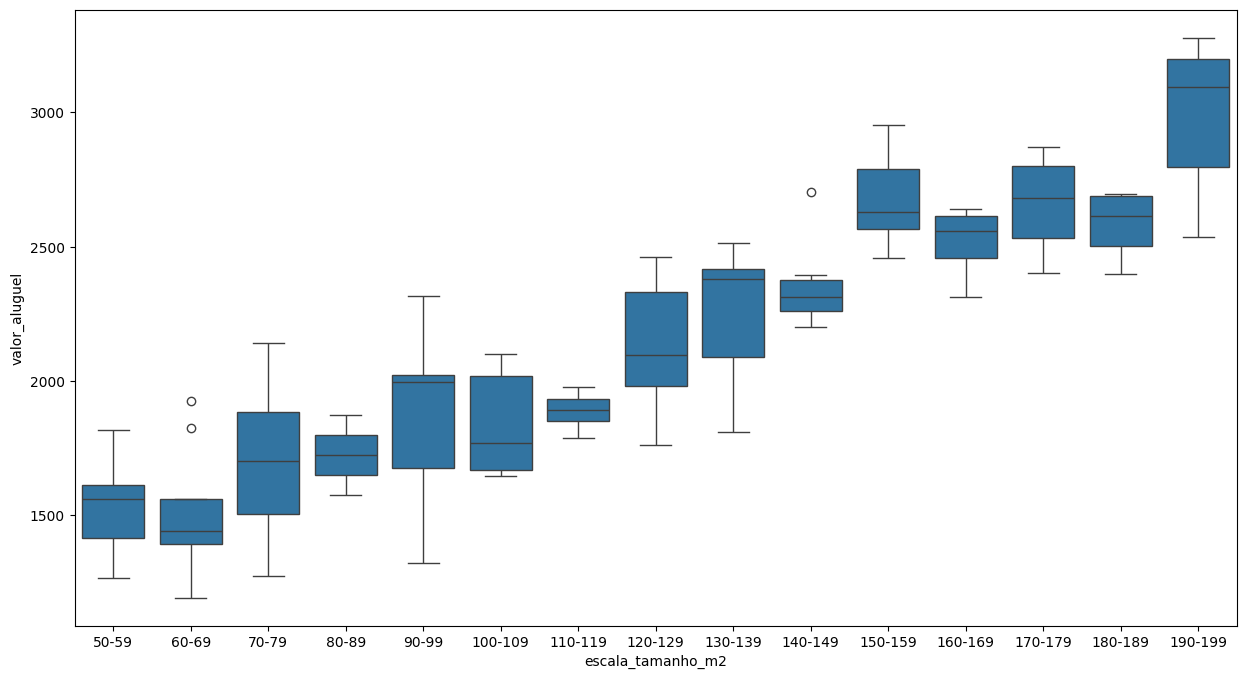

In [400]:
plt.figure(figsize=(15,8))
sns.boxplot(df_aluguel_bucketing, x='escala_tamanho_m2', y='valor_aluguel')

### Dividir os dados em conjuntos de treino e teste

In [401]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

In [402]:
# Dividir variáveis independentes X dependentes
X = df_aluguel.drop(columns='valor_aluguel')
y = df_aluguel['valor_aluguel']

In [403]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=51)

### Criar um pipeline para pré-processar os dados

In [404]:
# Pipeline
# Padronizar variáveis numéricas - tamanho_m2, idade_casa
# OneHotEncode nas variáveis categóricas nominais - n_quartos, garagem, localizacao_Periferia, localizacao_Subúrbio

# Nomes das Colunas
colunas_categoricas = ['n_quartos', 'garagem', 'localizacao_Periferia', 'localizacao_Subúrbio']
colunas_numericas = ['tamanho_m2', 'idade_casa'] 

In [405]:
# Transformer Categoricas
transformer_categorias = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [406]:
# Transformer Numéricas
transformer_numericas = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [407]:
# Criar um ColumnTransformer que encapsula todas as transformações
preprocessor = ColumnTransformer(
    transformers=[
        ('num', transformer_numericas, colunas_numericas),
        ('cat', transformer_categorias, colunas_categoricas)
    ]
)

In [408]:
# Criando o Pipeline principal = Pre Processamento + Treinamento
model_regr = Pipeline(steps=[('preprocessor', preprocessor),
                             ('regressor', LinearRegression())])

### Treinar o modelo de regressão linear utilizando o conjunto de treino

In [409]:
# Treinar Modelo
model_regr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

### Fazer predições sobre o conjunto de teste

In [410]:
# Calcular Predição
y_pred = model_regr.predict(X_test)

In [411]:
predicao_individual = {
    'n_quartos': 4,
    'garagem': 0,
    'localizacao_Periferia': True,
    'localizacao_Subúrbio': False,
    'idade_casa': 40.0,
    'tamanho_m2': 70.0,
}
sample_df = pd.DataFrame(predicao_individual, index=[1])

In [412]:
sample_df

,n_quartos,garagem,localizacao_Periferia,localizacao_Subúrbio,idade_casa,tamanho_m2
1,4,0,True,False,40.0,70.0


In [413]:
# Predição
model_regr.predict(sample_df)

array([1750.28059536])

### Calcular métricas de desempenho (R², MAE, RMSE)

In [414]:
# Calcular R2 score
r2_score(y_test, y_pred)

0.9922225734256035

R² = 0.9922 — o modelo explica 99,2% da variância no valor do aluguel. Trata-se de um resultado excelente, indicando que as variáveis escolhidas (tamanho, quartos, localização, garagem, idade) têm alto poder explicativo sobre o preço.

In [415]:
# Calcular MAE (Mean Absolute Error)
mean_absolute_error(y_test, y_pred)

40.19792356195517

Em média, o modelo erra R$ 40,20 por predição. Considerando que a média do aluguel no dataset é R$ 2.112,82, esse erro representa apenas 1,9% da média, o que é muito baixo.

In [416]:
# Calcular RMSE (Root Mean Absolute Error)
root_mean_squared_error(y_test, y_pred)

48.84169884717539

O RMSE é ligeiramente maior que o MAE, o que indica a presença de alguns erros um pouco maiores, mas ainda dentro de uma faixa muito aceitável (2,3% da média do aluguel).

### Analisar os resíduos para verificar a qualidade do modelo

In [417]:
# Calcular resíduos
residuos = y_test - y_pred

In [418]:
# Transformar resíduos na escala padrão
# (X - média) / desvio_padrão
from scipy.stats import zscore
residuos_std = zscore(residuos)

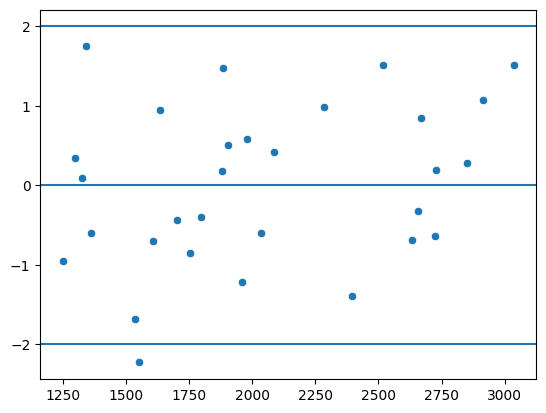

In [419]:
# Verificar linearidade dos resíduos: valores entre -2 e +2
# Verificar homocedasticidade: valores em torno da reta
sns.scatterplot(x=y_pred, y=residuos_std)
plt.axhline(y=0)
plt.axhline(y=-2)
plt.axhline(y=2)

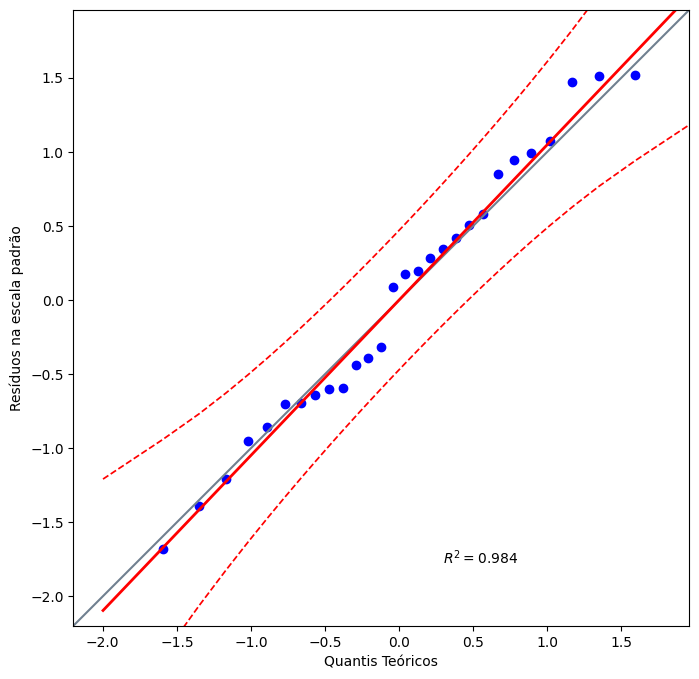

In [420]:
# Checar se resíduos seguem uma distribuição normal
# QQ Plot 
import pingouin as pg
plt.figure(figsize=(14,8))
pg.qqplot(residuos_std, dist='norm', confidence=0.95)
plt.xlabel('Quantis Teóricos')
plt.ylabel('Resíduos na escala padrão')
plt.show()

In [421]:
# Teste de Normalidade de Shapiro-Wilk
from scipy.stats import shapiro, kstest, anderson
from statsmodels.stats.diagnostic import lilliefors, het_goldfeldquandt

stat_shapiro, p_value_shapiro = shapiro(residuos)
print("Estatística do Teste: {} e P-Value: {}".format(stat_shapiro, p_value_shapiro))

Estatística do Teste: 0.9773716231521221 e P-Value: 0.752202076856514


In [422]:
# Teste de Kolmogorov-Smirnov
stat_ks, p_value_ks = kstest(residuos, 'norm')
print("Estatística do Teste: {} e P-Value: {}".format(stat_ks, p_value_ks))

Estatística do Teste: 0.5655848816997785 e P-Value: 1.37094949097952e-09


In [423]:
# Teste de Lilliefors
stat_ll, p_value_ll = lilliefors(residuos, dist='norm', pvalmethod='table')
print("Estatística do Teste: {} e P-Value: {}".format(stat_ll, p_value_ll))

Estatística do Teste: 0.08953393259006942 e P-Value: 0.7710151712647454


In [424]:
# Teste de Anderson-Darling
stat_and, critical_and, significance_and = anderson(residuos, dist='norm')
print("Estatística do Teste: {} e Valor Crítico: {}".format(stat_and, critical_and))

Estatística do Teste: 0.23638341522753947 e Valor Crítico: [0.546 0.614 0.732 0.85  1.007]


C:\Users\anitaa\AppData\Local\Temp\ipykernel_15784\171163493.py:2: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  stat_and, critical_and, significance_and = anderson(residuos, dist='norm')


In [425]:
critical_and

array([0.546, 0.614, 0.732, 0.85 , 1.007])

In [426]:
significance_and

array([15. , 10. ,  5. ,  2.5,  1. ])

In [427]:
# Teste de Homocedasticidade de Goldfeld-Quandt
pipe = Pipeline(steps=[('preprocessor', preprocessor)])
X_test_transformed = pipe.fit_transform(X_test)

In [428]:
X_test_transformed

array([[-0.75676331, -1.09309928,  0.        ,  0.        ,  1.        ,
         0.        ,  0.        ,  0.        ,  1.        ,  1.        ,
         0.        ,  1.        ,  0.        ],
       [ 1.6773658 ,  0.65294528,  0.        ,  0.        ,  1.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  1.        ,
         0.        ,  0.        ,  1.        ],
       [ 1.88491092,  0.34703317,  0.        ,  0.        ,  1.        ,
         0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
         1.        ,  1.        ,  0.        ],
       [-1.21973574, -0.68393331,  0.        ,  0.        ,  1.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  1.        ,
         0.        ,  1.        ,  0.        ],
       [-0.20955017, -1.56543711,  1.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  1.        ,
         0.        ,  1.        ,  0.        ],
       [-0.43986462,  1.638575

In [429]:
test_goldfeld = het_goldfeldquandt(residuos, X_test_transformed)
stat_goldfeld = test_goldfeld[0]
p_value_goldfeld = test_goldfeld[1]
print("Estatística do Teste: {} e P-Value: {}".format(stat_goldfeld, p_value_goldfeld))

Estatística do Teste: 0.34024490610974434 e P-Value: 0.8890790558826569


- Normalidade (Shapiro-Wilk / KS / Lilliefors): p-value > 0.05 (resíduos seguem distribuição normal)
- Homocedasticidade (Goldfeld-Quandt): p-value > 0.05 (variância constante dos resíduos)
- O modelo atende às premissas da regressão linear

### Analisar os coeficientes do modelo e discutir limitações e possíveis melhorias

In [430]:
# Extrair nomes das features após o preprocessamento
feature_names = model_regr.named_steps['preprocessor'].get_feature_names_out()

In [431]:
# Extrair coeficientes
coeficientes = model_regr.named_steps['regressor'].coef_

In [432]:
# Criar DataFrame ordenado
df_coef = (
    pd.DataFrame({'feature': feature_names, 'coeficiente': coeficientes})
    .sort_values('coeficiente', ascending=False)
    .reset_index(drop=True)
)

In [433]:
# Verificar coeficientes
df_coef

,feature,coeficiente
0,num__tamanho_m2,430.771579
1,cat__n_quartos_5,204.839662
2,cat__localizacao_Periferia_1,144.561421
3,cat__n_quartos_4,111.946356
4,cat__localizacao_Subúrbio_1,84.502099
5,cat__garagem_1,70.145514
6,cat__n_quartos_3,-18.730378
7,num__idade_casa,-66.524414
8,cat__garagem_0,-70.145514
9,cat__localizacao_Subúrbio_0,-84.502099


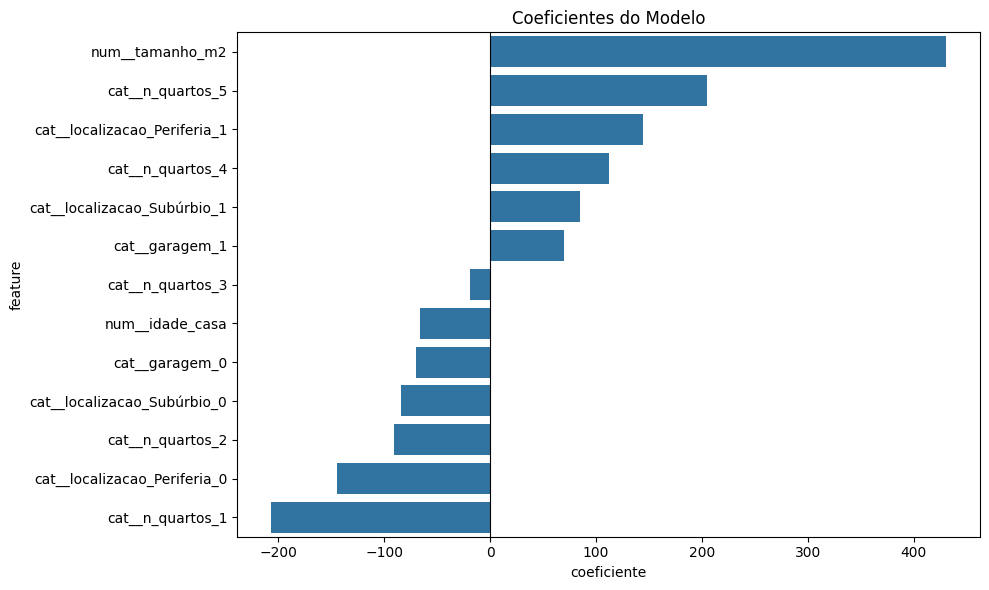

In [434]:
# Visualização dos coeficientes em gráfico
plt.figure(figsize=(10, 6))
sns.barplot(data=df_coef, x='coeficiente', y='feature')
plt.title('Coeficientes do Modelo')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

Analisando os coeficientes, observa-se que as variáveis com maior impacto positivo no aluguel são 'tamanho_m2' e 'n_quartos' entre 4 e 5. 

Em termos de limitações temos:
- Dataset pequeno (100 amostras), o que limita a generalização do modelo
- Ausência de dados mais específicos, como endereço, distância ao centro, etc, que poderiam deixar o modelo mais preciso
- Regressão linear assume relação linear entre variáveis, então pode não identificar interações mais complexas

Já em termos de melhorias, temos:
- Ampliar o dataset com mais amostras
- Incluir variáveis mais granulares
- Aplicar validações mais robustas em termos de desempenho